In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib
import matplotlib.pyplot as plt
print("Imports done!!")

Imports done!!


# Step 1 - load and clean data
1. load the cleaned titanic data set from the file `titanic_cleaned.csv` file (from Part A)
2. handle outliers if any in the df

In [2]:
titanic_df = pd.read_csv("titanic_cleaned.csv")
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
884,0,2,male,27.0,0,0,13.0000,S
885,1,1,female,19.0,0,0,30.0000,S
886,0,3,female,28.0,1,2,23.4500,S
887,1,1,male,26.0,0,0,30.0000,C


<Axes: >

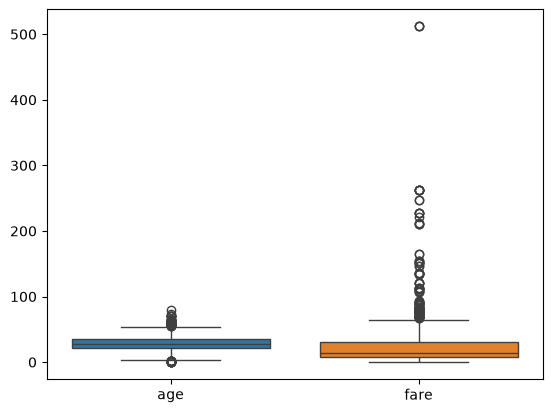

In [3]:
# check for outliers in age and fare columns
sns.boxplot(titanic_df[["age", "fare"]])

* There is one purticular outlier for fare which is very far from other outliers where fare > 500.
* as this is a single instance of fare being > 500 and other ones are in the range of <300 this might be an invalid entry and can be removed.

In [4]:
outlier_fare = titanic_df["fare"].max()
outlier_fare

np.float64(512.3292)

after removing the outlier


<Axes: >

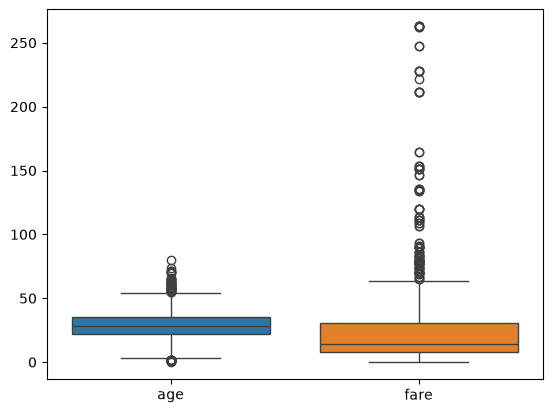

In [5]:
# remove the record for this outlier
titanic_df = titanic_df[titanic_df["fare"] != 512.3292]
print("after removing the outlier")
sns.boxplot(titanic_df[["age", "fare"]])

# Step 2 - Preprocessing
1. split training and testing data with split ratio = 0.2
2. create column transformed with standard scaling for numeric cols and one hot encoding for categorical cols

In [6]:
# split training and testing data
X = titanic_df.drop(columns=["survived"])
y = titanic_df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    stratify=y, 
    random_state=42
)
print("After Train - test split")
print("-"* 25)
print(f"{"Set":<10}{"Shape"}")
print("-"* 25)
print(f"{"X train":<10}{X_train.shape}")
print(f"{"y train":<10}{y_train.shape}")
print()
print(f"{"X test":<10}{X_test.shape}")
print(f"{"y test":<10}{y_test.shape}")

After Train - test split
-------------------------
Set       Shape
-------------------------
X train   (708, 7)
y train   (708,)

X test    (178, 7)
y test    (178,)


In [7]:
# create column transformer
cat_cols = ["sex", "embarked"]
num_cols = ["age", "fare"]
col_transformer = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(), cat_cols)
    ],
    remainder='passthrough'
)
col_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

# Step 3 - Train Models and Evaluate metrics
1. Train Logistic Regression model and get the metrics
2. Train Decision Tree model and get the metrics
3. Train Random Forest model and get the metrics

In [8]:
# Get the model instances for all three models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6),
    "Random Forest": RandomForestClassifier(random_state=42, max_depth=6, n_estimators=50)
}

In [9]:
metrics = {}
for i, model in models.items():
    metrics[i] = {}
    pipe = Pipeline(steps=[
        ('preprocessor', col_transformer),
        ('model', model)
    ])

    print(f"Training the Model - {i}....")
    pipe.fit(X_train, y_train)

    print(f"Testing with Training data....")
    y_train_pred = pipe.predict(X_train)
    y_train_proba = pipe.predict_proba(X_train)

    metrics[i]["Train Accuracy"] = accuracy_score(y_train, y_train_pred)
    metrics[i]["Train Precision"] = precision_score(y_train, y_train_pred)
    metrics[i]["Train Recall"] = recall_score(y_train, y_train_pred)
    metrics[i]["Train F1 Score"] = f1_score(y_train, y_train_pred)
    metrics[i]["Train CM"] = confusion_matrix(y_train, y_train_pred)
    metrics[i]["Train Probabilities"] = y_train_proba[:1]

    print(f"Testing with Test data....")
    y_test_pred = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)

    metrics[i]["Test Accuracy"] = accuracy_score(y_test, y_test_pred)
    metrics[i]["Test Precision"] = precision_score(y_test, y_test_pred)
    metrics[i]["Test Recall"] = recall_score(y_test, y_test_pred)
    metrics[i]["Test F1 Score"] = f1_score(y_test, y_test_pred)
    metrics[i]["Test CM"] = confusion_matrix(y_test, y_test_pred)
    metrics[i]["Test Probabilities"] = y_test_proba[:, 1]

Training the Model - Logistic Regression....
Testing with Training data....
Testing with Test data....
Training the Model - Decision Tree....
Testing with Training data....
Testing with Test data....
Training the Model - Random Forest....
Testing with Training data....
Testing with Test data....


In [10]:
print("Training results")
print("-" * 80)
print(f"{"Metric":<20}{"Logistic Regression":<25}{"Decision Tree":<20}{"Random Forest":<20}")
print("-" * 80)
metric_labels = [i for i in metrics["Logistic Regression"]]
for label in metric_labels:
    if label not in ["Test CM", "Test Probabilities", "Train CM", "Train Probabilities"]:
        print(f"{label:<20}{round(metrics["Logistic Regression"][label], 4):<25}{round(metrics["Decision Tree"][label],4):<20}{round(metrics["Random Forest"][label], 4)}")

Training results
--------------------------------------------------------------------------------
Metric              Logistic Regression      Decision Tree       Random Forest       
--------------------------------------------------------------------------------
Train Accuracy      0.8093                   0.8771              0.887
Train Precision     0.7597                   0.8856              0.8921
Train Recall        0.7286                   0.777               0.7993
Train F1 Score      0.7438                   0.8277              0.8431
Test Accuracy       0.7697                   0.7416              0.7978
Test Precision      0.7547                   0.6667              0.7857
Test Recall         0.5882                   0.6471              0.6471
Test F1 Score       0.6612                   0.6567              0.7097


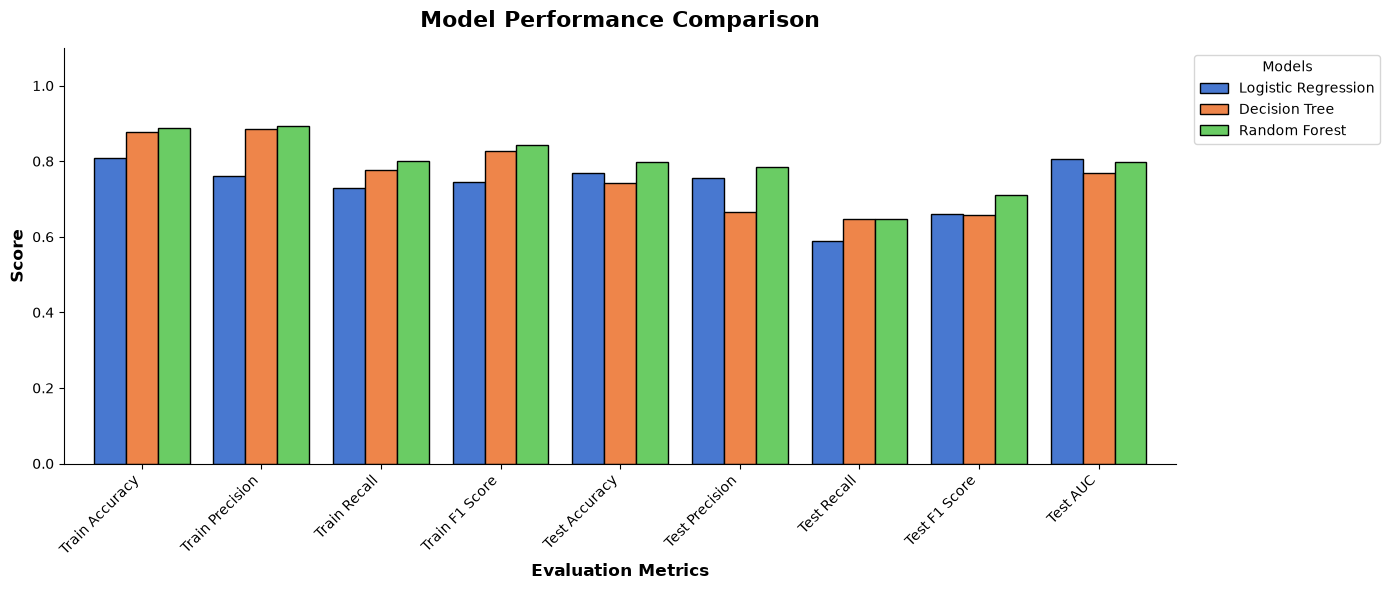

In [22]:
filtered_metrics = {}
for model, model_data in metrics.items():
    y_proba = model_data["Test Probabilities"]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    model_auc = auc(fpr, tpr)

    filtered_metrics[model] = {
        metric_name: value 
        for metric_name, value in model_data.items() if 'CM' not in metric_name and 'Probabilities' not in metric_name
    }
    filtered_metrics[model]["Test AUC"] = model_auc
df_metrics = pd.DataFrame(filtered_metrics)
fig, ax = plt.subplots(figsize=(14, 6))
df_metrics.plot(kind='bar', ax=ax, width=0.8, color=sns.color_palette("muted"), edgecolor='black')
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_xlabel('Evaluation Metrics', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.1) 
plt.xticks(rotation=45, ha='right')
ax.legend(title='Models', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

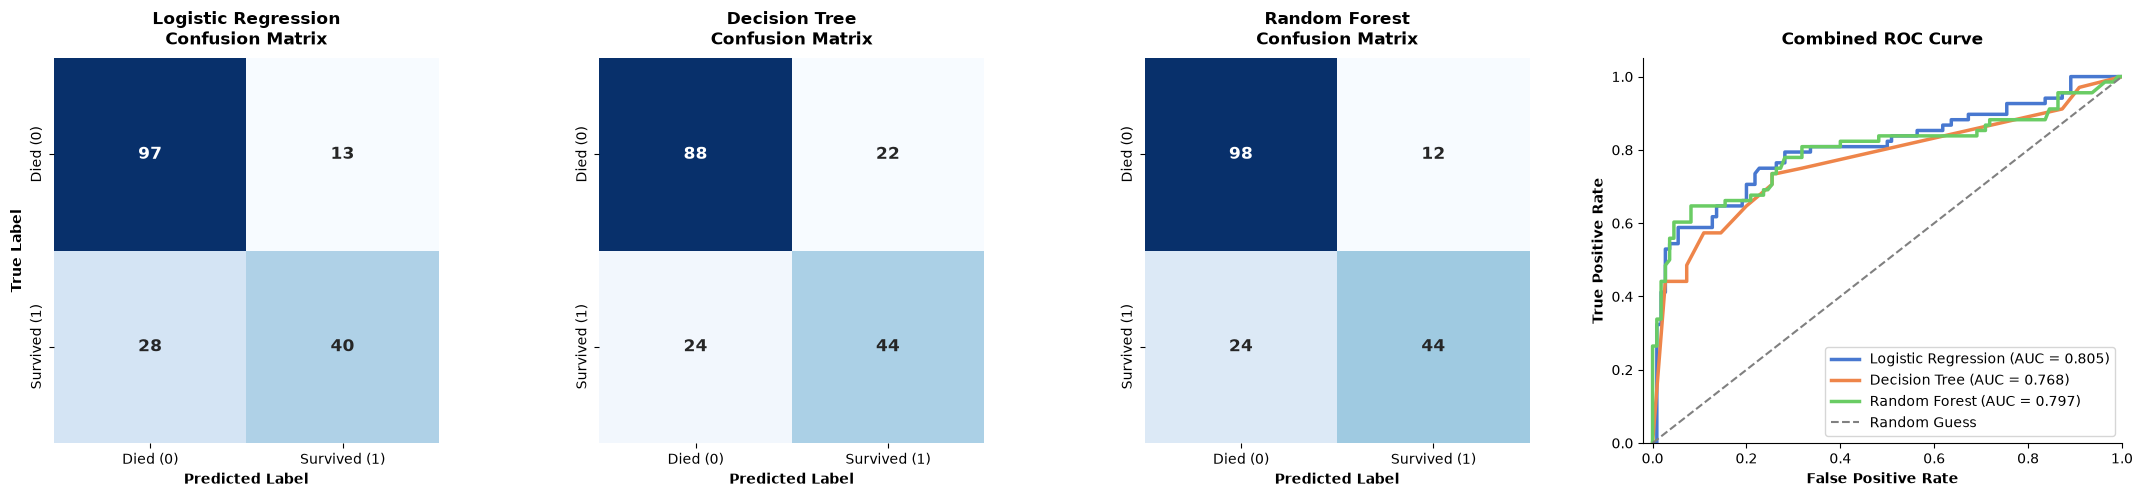

In [21]:
# display confusion matrix and RoC curve
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(22, 5))
for idx, (model_name, model_metrics) in enumerate(metrics.items()):
    ax = axes[idx]
    cm = model_metrics["Test CM"]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                cbar=False, square=True, annot_kws={"size": 12, "weight": "bold"},
                xticklabels=['Died (0)', 'Survived (1)'], 
                yticklabels=['Died (0)', 'Survived (1)'])
    
    ax.set_title(f'{model_name}\nConfusion Matrix', fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontweight='bold')
    if idx == 0:
        ax.set_ylabel('True Label', fontweight='bold')
ax_roc = axes[3]
roc_colors = sns.color_palette("muted", 3)

for idx, (model_name, model_metrics) in enumerate(metrics.items()):
    # Extract the probabilities you saved earlier
    y_proba = model_metrics["Test Probabilities"]
    
    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot each model's line on the same axis
    ax_roc.plot(fpr, tpr, color=roc_colors[idx], lw=2.5, label=f'{model_name} (AUC = {roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess')

ax_roc.set_xlim([-0.02, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate', fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontweight='bold')
ax_roc.set_title('Combined ROC Curve', fontweight='bold', pad=10)
ax_roc.legend(loc="lower right", frameon=True, fontsize=10)

ax_roc.spines['top'].set_visible(False)
ax_roc.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()